In [31]:
import pandas as pd
import numpy as np

In [33]:
data = pd.read_csv("C:/Users/Durosimi/PROJECTS/Parkinson/data/processed/featured_data.csv")

In [35]:
data.columns

Index(['subject', 'age', 'sex', 'test_time', 'motor_updrs', 'total_updrs',
       'jitter', 'jitter_abs', 'jitter_rap', 'jitter_ppq5', 'jitter_ddp',
       'shimmer', 'shimmer_db', 'shimmer_apq3', 'shimmer_apq5',
       'shimmer_apq11', 'shimmer_dda', 'nhr', 'hnr', 'rpde', 'dfa', 'ppe'],
      dtype='object')

In [4]:
data = data.sort_values(["subject", "test_time"]).reset_index(drop=True)


In [5]:
data["motor_updrs_lag1"] = (
    data.groupby("subject")["motor_updrs"].shift(1)
)


In [6]:
data["delta_time"] = (
    data.groupby("subject")["test_time"].diff()
)


In [7]:
data["delta_updrs"] = (
    data.groupby("subject")["motor_updrs"].diff()
)


In [8]:
data["updrs_rolling_mean_3"] = (
    data.groupby("subject")["motor_updrs"]
    .rolling(window=3)
    .mean()
    .reset_index(level=0, drop=True)
)

data["updrs_rolling_std_3"] = (
    data.groupby("subject")["motor_updrs"]
    .rolling(window=3)
    .std()
    .reset_index(level=0, drop=True)
)


In [9]:
data = data.dropna().reset_index(drop=True)


In [10]:
y = data["motor_updrs"]

feature_cols = [
    # Voice features
    "jitter", "shimmer", "hnr",
    "dfa", "rpde", "ppe",

    # Demographics
    "age", "sex",

    # Temporal features
    "motor_updrs_lag1",
    "delta_time",
    "delta_updrs",
    "updrs_rolling_mean_3",
    "updrs_rolling_std_3"
]

X = data[feature_cols]


In [11]:
data.to_csv("C:/Users/Durosimi/PROJECTS/Parkinson/data/processed/features_temporal.csv", index=False)


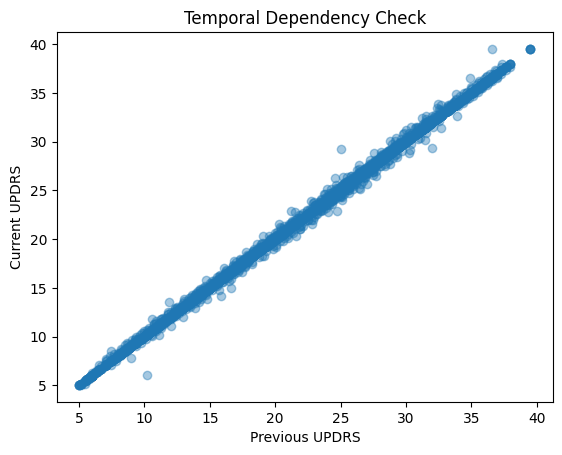

In [12]:
import matplotlib.pyplot as plt

plt.scatter(
    data["motor_updrs_lag1"],
    data["motor_updrs"],
    alpha=0.4
)
plt.xlabel("Previous UPDRS")
plt.ylabel("Current UPDRS")
plt.title("Temporal Dependency Check")
plt.show()
